# GWR Results Visualisation

In [143]:
# --- Imports ---
import rdata
import numpy as np
import pandas as pd
import geopandas as gpd


In [144]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
from scipy.spatial import cKDTree

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


## Configuration

In [163]:
# --- EDIT THESE ---
GPKG_PATH = r"GWNBR_Output\Final_Results\ped_gwnbr_results.gpkg"       # per-location GWR results (points/polygons + coefficients)
RESULTS_PATH = r"GWNBR_Output\Final_Results\gwnbr_full_result.rds"    # pickled dict/object with bandwidth, measures, ENP, global_measures, etc.
GLOBAL_RESULTS_PATH = r"GWNBR_Output\glm_nb_results.RData"  # CSV with global model results (coefficients, t-values, p-values)
FORWARD_SELECTION_PATH = r"GWNBR_Output\fs_final.csv"
BORDER_PATH = r"Data\Supplementaries\lds-nz-coastlines-topo-150k-SHP\nz-coastlines-topo-150k.shp"      # border layer for plotting
# If your model has categorical/dummy layers, drop them from significance shading below by adding to this list
EXCLUDE_FROM_COEF_PLOTS = ["b_alpha","b_Intercept"]   # e.g. ["b_alpha"] if you don't want the dispersion parameter mapped like a covariate


## Load data

In [146]:
gdf = gpd.read_file(GPKG_PATH)
border = gpd.read_file(BORDER_PATH).to_crs(gdf.crs)


def plot_border_under(ax):
    border.plot(ax=ax, color="black", linewidth=1.5, zorder=1)


def zoom_to_data(ax, padding=0.2):
    min_x, min_y, max_x, max_y = gdf.total_bounds
    width = max_x - min_x
    height = max_y - min_y
    ax.set_xlim(min_x - padding * width, max_x + padding * width)
    ax.set_ylim(min_y - padding * height, max_y + padding * height)


print(f"Loaded {len(gdf)} rows, CRS: {gdf.crs}")
print(f"Loaded area border with {len(border)} feature(s)")
gdf.head()


Loaded 5130 rows, CRS: EPSG:2193
Loaded area border with 2 feature(s)


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'GWNBR_Output\Final_Results\ped_gwnbr_results.gpkg' may only be partially supported
  return ogr_read(


,elevation_range,elevation_max,gradient,Rural_settlement_distances,Small_urban_distances,trail_density_400m,Forest_proportion,Grassland_proportion,Scrubland_proportion,Water_Bodies_proportion,...,b_degree_centrality,b_alpha,se_Intercept,se_closeness_centrality,se_parking_distance,se_elevation_max,se_trail_density_400m,se_degree_centrality,se_alpha,geometry
0,14.480400,62.909615,0.049561,947.599874,947.599874,0.024546,0.578964,0.356940,0.064096,0.000000e+00,...,-1940.378012,1.383206,2.112738,164.972552,0.000556,0.006987,12.198478,1571.677117,0.123068,"LINESTRING (1566602.329 5172833.423, 1566586.0..."
1,41.272972,161.233261,0.083568,0.000000,0.000000,0.027764,0.107669,0.512043,0.000000,8.881784e-15,...,-1893.836428,1.436739,1.982866,149.668541,0.000518,0.006651,12.181479,1599.475539,0.126705,"LINESTRING (1566699.839 5172258.991, 1566701.8..."
2,0.803947,40.802662,0.016288,697.726627,697.726627,0.031185,0.785697,0.214303,0.000000,2.087219e-14,...,-1942.239352,1.394544,2.036449,159.529153,0.000534,0.006747,12.150705,1574.903797,0.122673,"LINESTRING (1566455.64 5172648.094, 1566461.29..."
3,0.056458,40.673653,0.004056,871.572754,871.572754,0.033011,1.000000,0.000000,0.000000,0.000000e+00,...,-1920.958560,1.391085,2.054602,161.554342,0.000539,0.006797,12.157758,1570.986170,0.122494,"LINESTRING (1566556.846 5172732.852, 1566543.2..."
4,4.910843,79.592880,0.117539,706.377818,706.377818,0.042154,0.000000,0.902029,0.097971,0.000000e+00,...,-1871.502319,1.403479,1.982301,157.206783,0.000518,0.006560,12.105818,1568.915407,0.122188,"LINESTRING (1566745.34 5172655.19, 1566740.152..."


In [ ]:
with open(RESULTS_PATH, "rb") as f:
    parsed_data = rdata.parser.parse_file(RESULTS_PATH)
    results = rdata.conversion.convert(parsed_data)

print("Top-level keys in results object:")
try:
    print(list(results.keys()))
except AttributeError:
    print("(results is not a dict — it looks like a fitted GWRResults object; adjust access below accordingly)")

parsed_global_data = rdata.parser.parse_file(GLOBAL_RESULTS_PATH)
global_results = rdata.conversion.convert(parsed_global_data)
print("Top-level keys in global results object:")
try:
    print(list(global_results.keys()))
except AttributeError:
    print(type(global_results))


Top-level keys in results object:
[np.str_('general_bandwidth'), np.str_('fitted_values'), np.str_('measures'), np.str_('ENP'), np.str_('mgwr_param_estimates'), np.str_('alpha_level_5_pct'), np.str_('t_critical'), np.str_('mgwr_se'), np.str_('global_param_estimates'), np.str_('t_test_dfs'), np.str_('global_measures')]
Top-level keys in global results object:
['coef_table', 'irr_table', 'model_stats']
Global model_stats:
   null.deviance  df.null        logLik           AIC           BIC  \
1    7574.892706     5129 -37997.693132  76011.386264  76063.729151   

      deviance  df.residual  nobs     theta  SE_theta  
1  6537.946979         5123  5130  0.474329  0.007721  


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py:918: UserWarning: Missing constructor for R class "mgwnbr_model". The underlying R object is returned instead.
  warnings.warn(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py:918: UserWarning: Missing constructor for R class "logLik". The underlying R object is returned instead.
  warnings.warn(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py:918: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py:918: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\rdata\conversion\_conversion.py

## Count and Area of Study Plots

## Foward Variable Selection

In [148]:
# Load CSV of forward selection results
fs_df = pd.read_csv(FORWARD_SELECTION_PATH)
# Filter Selected
selected_fs_df = fs_df[fs_df['Status_Selected'] == "SELECTED"]

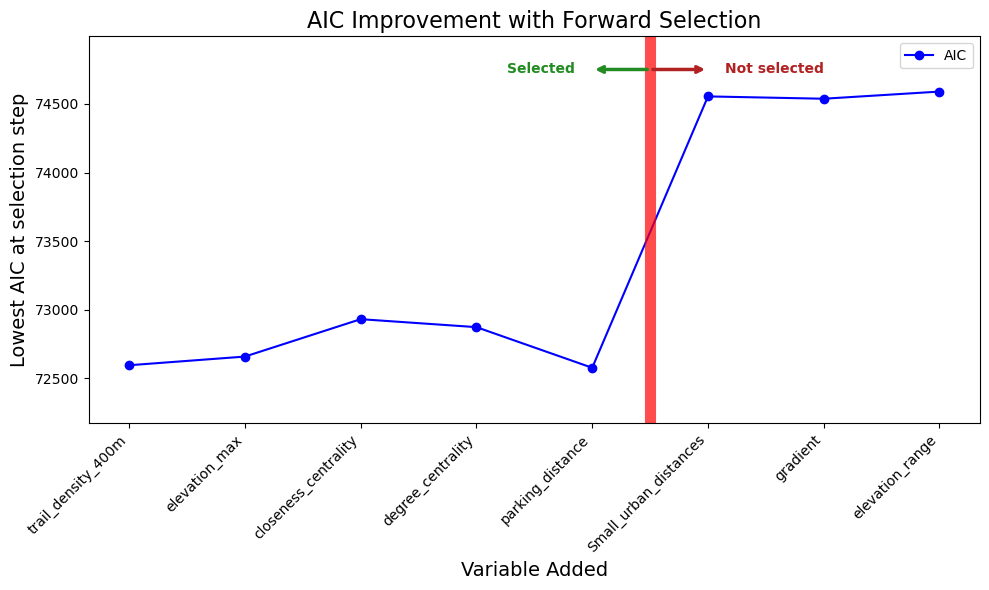

In [149]:
# Plot AIC improvement with each added variable based on iteration, highlighting minimum AIC
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.plot(
    selected_fs_df["Iteration"], selected_fs_df["AIC"],
    marker="o", linestyle="-", color="blue", label="AIC"
)
ax.axvline(x=5.5, color="red", linestyle="-", linewidth=8, alpha=0.7)

# Add directional labels around the selected iteration.
y_min = selected_fs_df["AIC"].min()
y_max = selected_fs_df["AIC"].max()
y_range = max(y_max - y_min, 1)

arrow_y = y_max + 0.08 * y_range
ax.annotate(
    "", xy=(5, arrow_y), xytext=(5.5, arrow_y),
    arrowprops={"arrowstyle": "->", "color": "forestgreen", "lw": 2.5},
)
ax.text(4.85, arrow_y, "Selected", color="forestgreen", ha="right", va="center", weight="bold")
ax.annotate(
    "", xy=(6, arrow_y), xytext=(5.5, arrow_y),
    arrowprops={"arrowstyle": "->", "color": "firebrick", "lw": 2.5},
)
ax.text(6.15, arrow_y, "Not selected", color="firebrick", ha="left", va="center", weight="bold")
ax.set_ylim(y_min-0.2 * y_range, y_max + 0.2 * y_range)

ax.set_title("AIC Improvement with Forward Selection", fontsize=16)
ax.set_xlabel("Variable Added", fontsize=14)
ax.set_ylabel("Lowest AIC at selection step", fontsize=14)
ax.set_xticks(selected_fs_df["Iteration"])
ax.set_xticklabels(selected_fs_df["Tested_Variable"], rotation=45, ha="right")
ax.legend()
fig.tight_layout()
plt.show()

## Identify parameter columns

We pull the `b_*` / `se_*` pairs straight from the GeoDataFrame columns rather than hardcoding variable
names, so this stays correct if the model specification changes.


In [150]:
b_cols = [c for c in gdf.columns if c.startswith("b_")]
se_cols = [c for c in gdf.columns if c.startswith("se_")]

# pair them up by variable name
param_names = [c[2:] for c in b_cols]
missing_se = [p for p in param_names if f"se_{p}" not in gdf.columns]
if missing_se:
    print("Warning — no matching se_ column for:", missing_se)

param_names = [p for p in param_names if f"b_{p}" not in EXCLUDE_FROM_COEF_PLOTS]
print(f"Found {len(param_names)} parameters:")
param_names


Found 5 parameters:


['closeness_centrality',
 'parking_distance',
 'elevation_max',
 'trail_density_400m',
 'degree_centrality']

## 1. Parameter estimate maps

Each panel shows the local coefficient for one explanatory variable, on a diverging colour scale
centred at zero (blue = negative effect, red = positive effect) so the sign and relative strength
of the local relationship is easy to read at a glance.


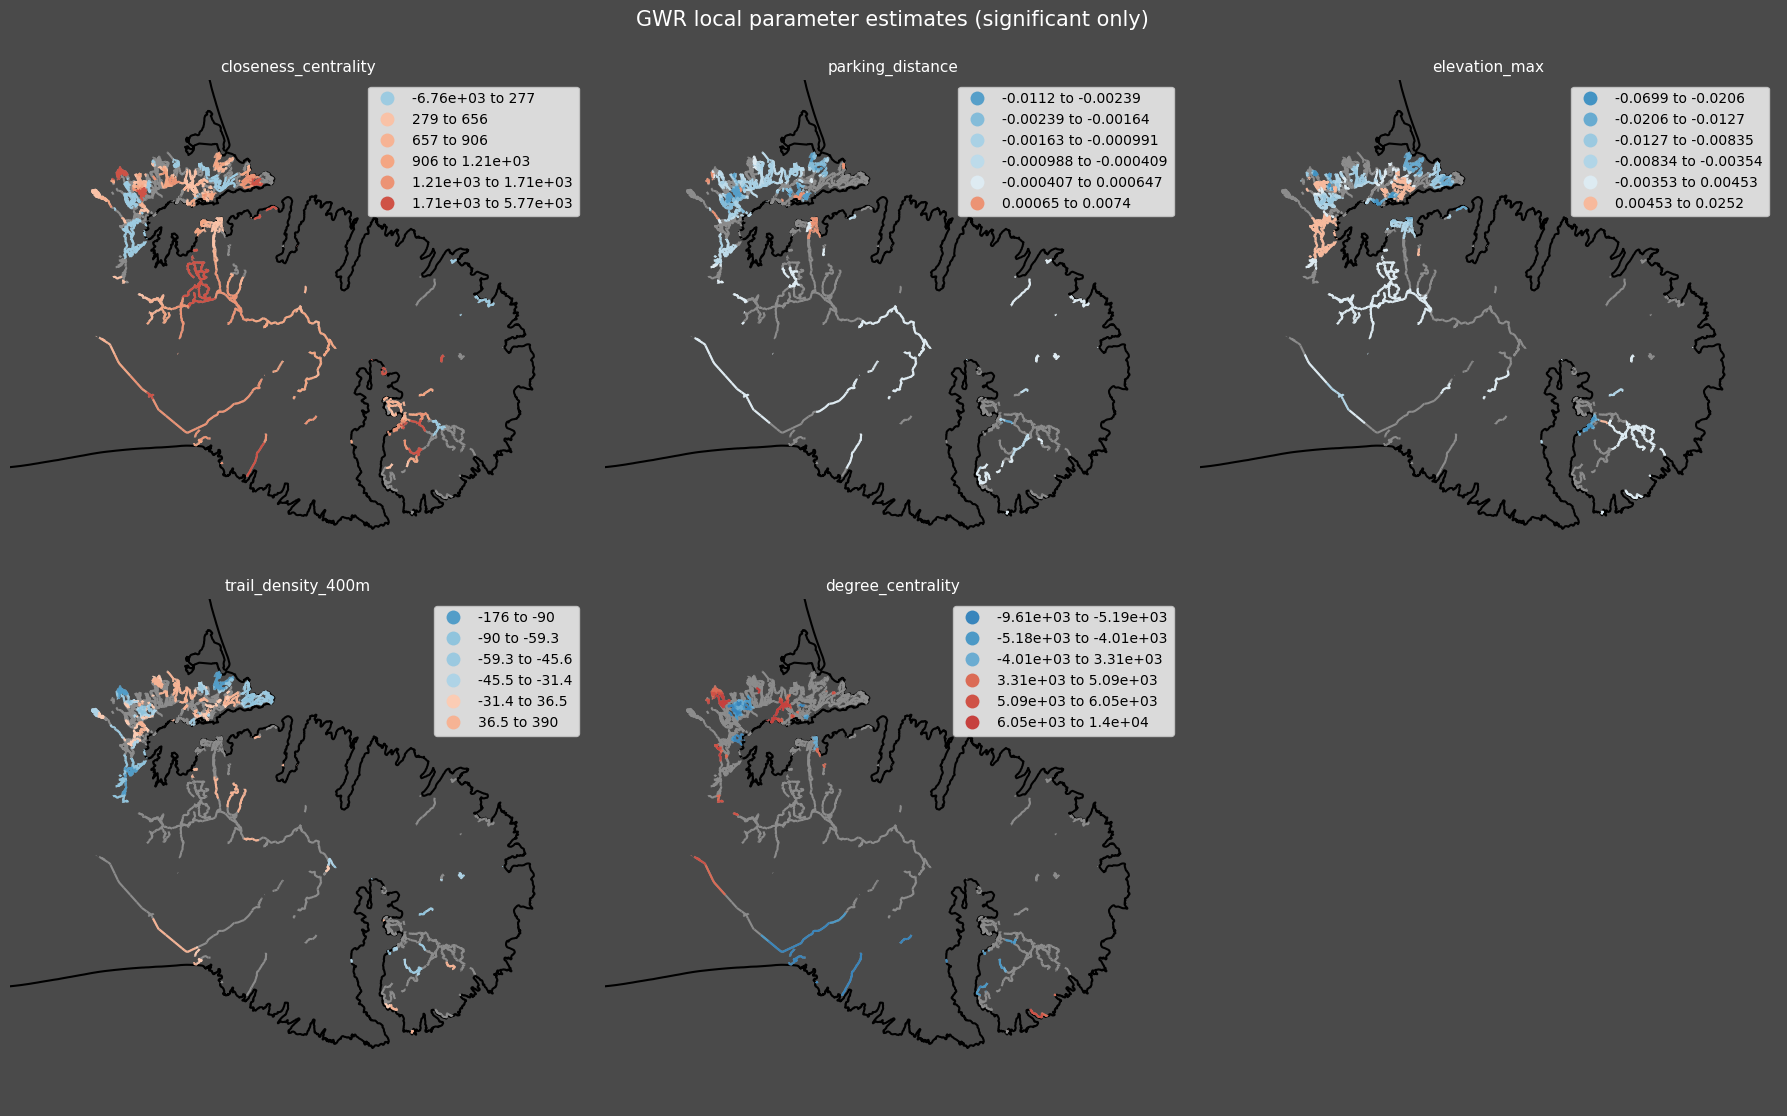

In [159]:
def plot_coefficient_grid(gdf, param_names, ncols=3, cmap="RdBu_r", markersize=8, crit_t=1.96, ngroups=6):
    from matplotlib.colors import ListedColormap

    n = len(param_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 5.5 * nrows), facecolor="#4a4a4a"
    )
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(param_names):
        ax = axes[i]
        b_col, se_col = f"b_{p}", f"se_{p}"
        t = gdf[b_col] / gdf[se_col]
        significant = t.abs() >= crit_t
        values = gdf.loc[significant, b_col].dropna().astype(float)

        plot_border_under(ax)
        gdf.plot(ax=ax, color="#8c8c8c", markersize=markersize, zorder=2)

        if len(values):
            ranks = values.rank(method="first")
            group_numbers = pd.qcut(ranks, q=ngroups, labels=False).astype(int)
            group_labels = []
            group_centres = []
            for group in range(ngroups):
                group_values = values[group_numbers == group]
                group_labels.append(f"{group_values.min():.3g} to {group_values.max():.3g}")
                group_centres.append(group_values.median())

            max_abs = max(abs(values.min()), abs(values.max()))
            zero_norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
            normalized = zero_norm(group_centres)
            centered = normalized - 0.5
            saturated = 0.5 + np.sign(centered) * 0.5 * (2 * np.abs(centered)) ** 0.5
            group_cmap = ListedColormap(plt.get_cmap(cmap)(saturated))

            grouped = pd.Series(np.nan, index=gdf.index, dtype=object)
            grouped.loc[group_numbers.index] = [group_labels[group] for group in group_numbers]
            grouped = pd.Categorical(grouped, categories=group_labels, ordered=True)

            gdf.assign(_coefficient_group=grouped).plot(
                column="_coefficient_group", ax=ax, cmap=group_cmap,
                categorical=True, markersize=markersize, legend=True,
                legend_kwds={"loc": "upper right"}, zorder=3,
            )

        zoom_to_data(ax)
        ax.set_facecolor("#4a4a4a")
        ax.set_title(f"{p}", fontsize=11, color="white")
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_facecolor("#4a4a4a")
        axes[j].set_axis_off()

    fig.suptitle(
        "GWR local parameter estimates (significant only)",
        fontsize=15, y=1.01, color="white"
    )
    fig.tight_layout()
    return fig

fig1 = plot_coefficient_grid(gdf, param_names)
plt.show()

### Significance (pseudo t-values)

`t = b / se`. Values with `|t| < 1.96` are (approximately) not significant at the 95% level and are
shown hatched/greyed out on each map so the significant "hotspots" of each relationship stand out.


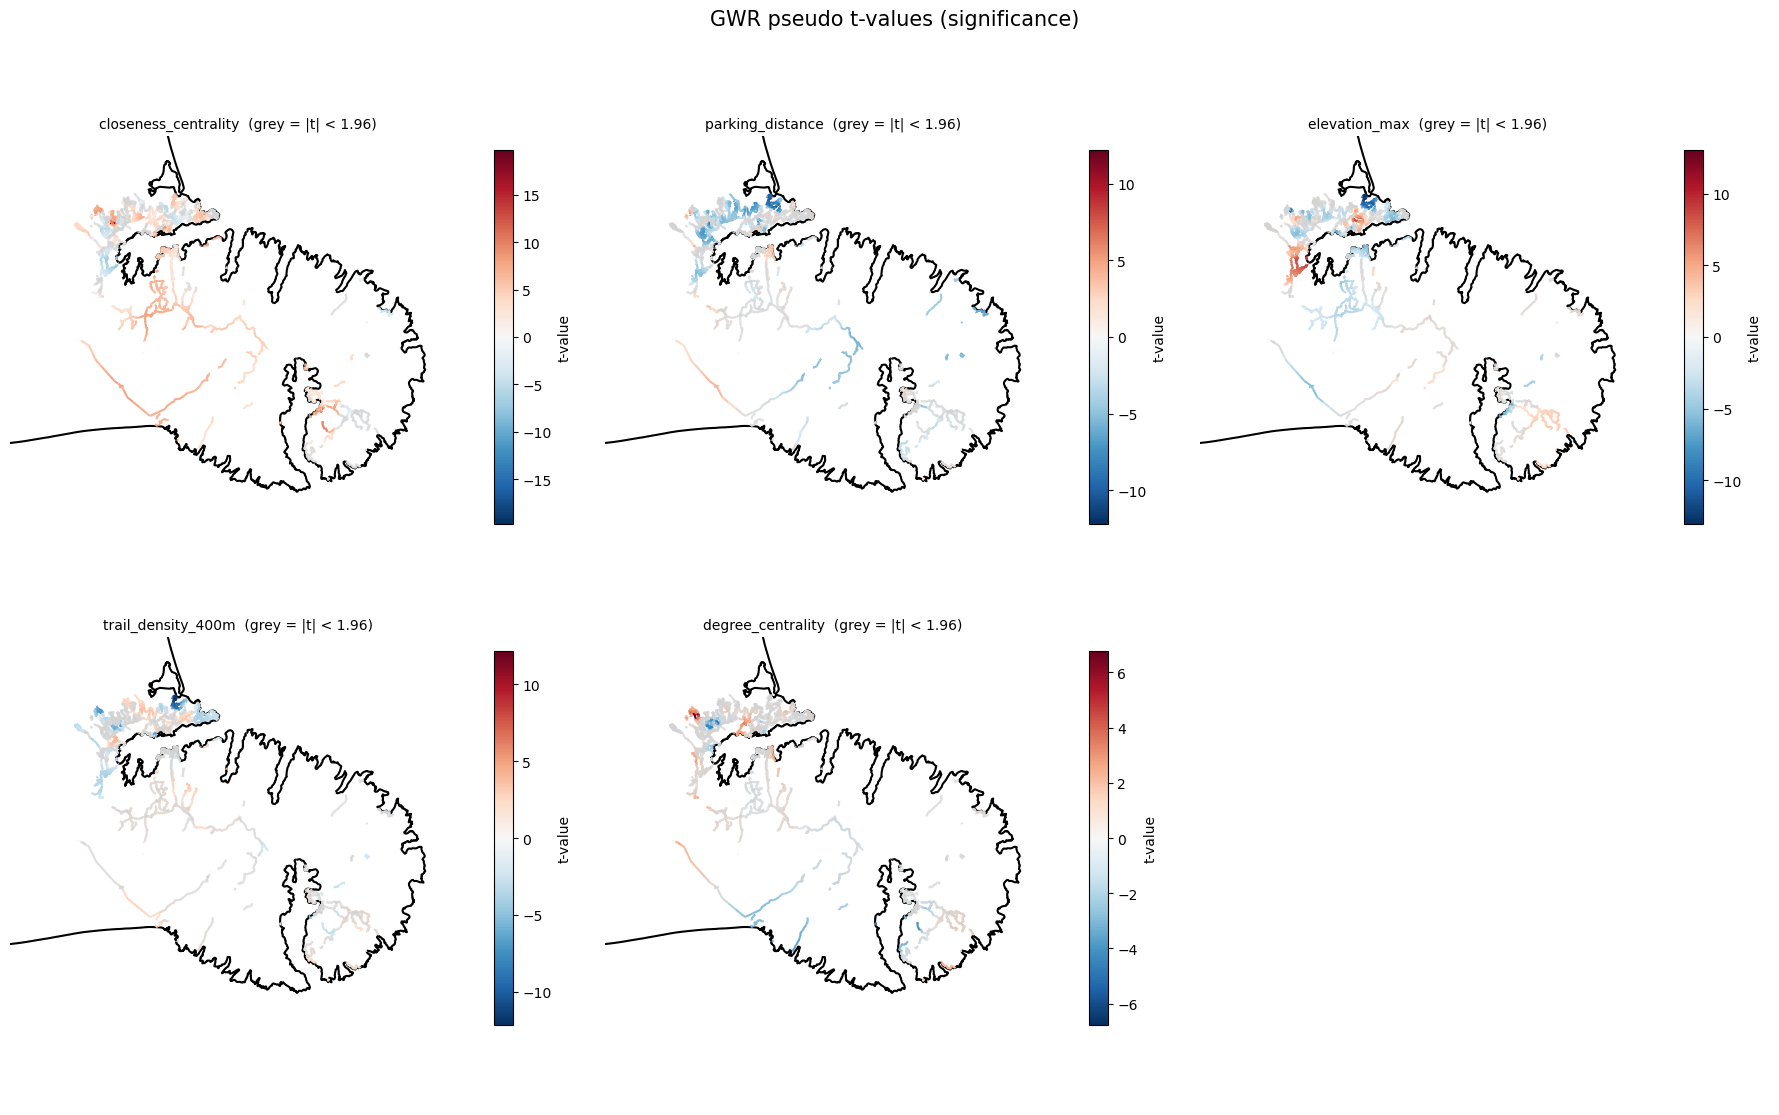

In [152]:
def plot_tvalue_grid(gdf, param_names, ncols=3, cmap="RdBu_r", markersize=8, crit_t=1.96):
    n = len(param_names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, p in enumerate(param_names):
        ax = axes[i]
        b_col, se_col = f"b_{p}", f"se_{p}"
        t = gdf[b_col] / gdf[se_col]
        tmax = np.nanmax(np.abs(t))
        norm = TwoSlopeNorm(vmin=-tmax, vcenter=0, vmax=tmax)

        plot_border_under(ax)
        gdf.assign(_t=t).plot(
            column="_t", ax=ax, cmap=cmap, norm=norm,
            markersize=markersize, legend=True,
            legend_kwds={"shrink": 0.7, "label": "t-value"}, zorder=2,
        )

        not_sig = gdf[np.abs(t) < crit_t]
        if len(not_sig):
            not_sig.plot(ax=ax, color="lightgrey", markersize=markersize, alpha=0.6, zorder=3)

        zoom_to_data(ax)
        ax.set_title(f"{p}  (grey = |t| < {crit_t})", fontsize=10)
        ax.set_axis_off()

    for j in range(n, len(axes)):
        axes[j].set_axis_off()

    fig.suptitle("GWR pseudo t-values (significance)", fontsize=15, y=1.01)
    fig.tight_layout()
    return fig

fig2 = plot_tvalue_grid(gdf, param_names)
plt.show()


## 2. Local R²

Spatial variation in how well the model fits at each location.


In [153]:
print("No 'localR2' found in the results object — falling back to a manual adaptive-neighbourhood "
        "approximation using the fitted bandwidth. Replace this with the real mgwr localR2 if you have it.")

bw = results["general_bandwidth"][0] if isinstance(results, dict) else results.bw
# Use centroids so this also works for polygon/line geometries, not just points.
# Centroids on a geographic (lat/lon) CRS are inaccurate for distance-based neighbour search,
# so reproject to the data's own projected CRS first if needed.
if gdf.crs is not None and gdf.crs.is_geographic:
    print(f"CRS {gdf.crs} is geographic — reprojecting to its UTM equivalent for centroid/distance calcs.")
    gdf_proj = gdf.to_crs(gdf.estimate_utm_crs())
else:
    gdf_proj = gdf
centroids = gdf_proj.geometry.centroid
coords = np.column_stack([centroids.x, centroids.y])
y = gdf["Y"].to_numpy(dtype=float)
yhat = gdf["yhat"].to_numpy(dtype=float)

tree = cKDTree(coords)
k = int(min(bw, len(gdf)))  # neighbourhood size capped to dataset size
_, idx = tree.query(coords, k=k)

local_r2 = np.empty(len(gdf))
for i in range(len(gdf)):
    nbrs = idx[i]
    y_local = y[nbrs]
    yhat_local = yhat[nbrs]
    ss_res = np.sum((y_local - yhat_local) ** 2)
    ss_tot = np.sum((y_local - y_local.mean()) ** 2)
    local_r2[i] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
source = f"manual approximation (k={k} nearest neighbours)"

gdf["_local_r2"] = local_r2
print(f"Local R2 source: {source}")
print(gdf["_local_r2"].describe())


No 'localR2' found in the results object — falling back to a manual adaptive-neighbourhood approximation using the fitted bandwidth. Replace this with the real mgwr localR2 if you have it.
Local R2 source: manual approximation (k=264 nearest neighbours)
count    5130.000000
mean        0.283147
std         0.101595
min        -0.559430
25%         0.207552
50%         0.281937
75%         0.354588
max         0.595617
Name: _local_r2, dtype: float64


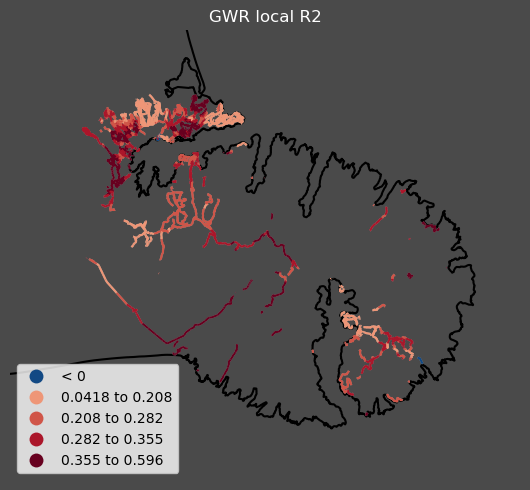

In [182]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 5), facecolor="#4a4a4a")
ax.set_facecolor("#4a4a4a")

local_r2_values = gdf["_local_r2"].astype(float)
non_negative = local_r2_values[local_r2_values >= 0].dropna()

grouped = pd.Series(np.nan, index=gdf.index, dtype=object)
grouped.loc[local_r2_values < 0] = "< 0"
positive_labels = []
if len(non_negative):
    positive_ranks = non_negative.rank(method="first")
    positive_groups = pd.qcut(positive_ranks, q=4, labels=False).astype(int)
    for group in range(4):
        group_values = non_negative[positive_groups == group]
        label = f"{group_values.min():.3g} to {group_values.max():.3g}"
        positive_labels.append(label)
        grouped.loc[group_values.index] = label

class_labels = ["< 0"] + positive_labels
grouped = pd.Categorical(grouped, categories=class_labels, ordered=True)

plot_border_under(ax)
gdf.plot(ax=ax, color="#8c8c8c", markersize=10, zorder=2)
redblue_cmap = plt.get_cmap("RdBu_r")
redblue_colors = np.vstack([
    redblue_cmap(0.05),
    redblue_cmap(np.linspace(0.72, 1.0, len(class_labels) - 1)),
])
gdf.assign(_local_r2_group=grouped).plot(
    column="_local_r2_group",
    ax=ax,
    cmap=ListedColormap(redblue_colors),
    categorical=True,
    markersize=10,
    legend=True,
    legend_kwds={"loc": "lower left"},
    zorder=3,
)
zoom_to_data(ax)

ax.set_title("GWR local R2", color="white")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## 3. Standardised local (GWR) residuals

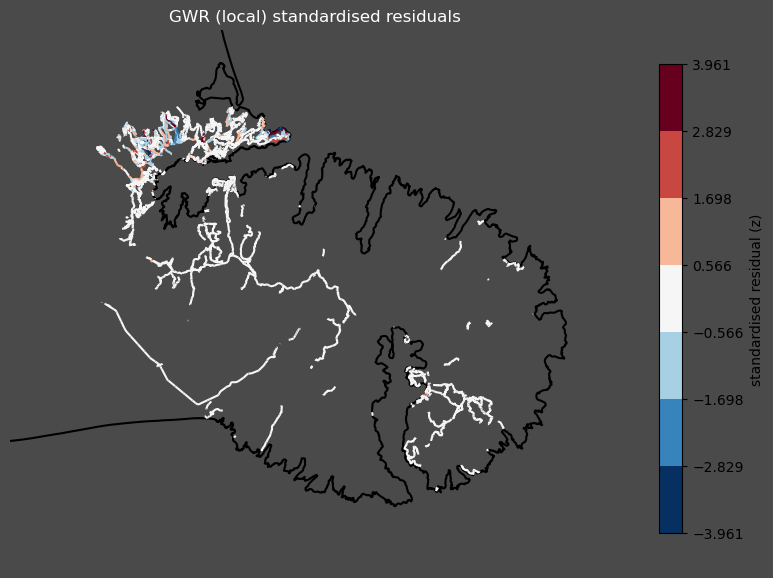

In [176]:
from matplotlib.colors import BoundaryNorm, ListedColormap

gdf["res_std"] = (gdf["res"] - gdf["res"].mean()) / gdf["res"].std()

fig, ax = plt.subplots(figsize=(8, 7), facecolor="#4a4a4a")
ax.set_facecolor("#4a4a4a")
vmax = np.nanmax(np.abs(gdf["res_std"]))/3
boundaries = np.linspace(-vmax, vmax, 8)
norm = BoundaryNorm(boundaries, ncolors=7, clip=True)
residual_cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, 7)))

plot_border_under(ax)
gdf.plot(
    column="res_std", ax=ax, cmap=residual_cmap, norm=norm,
    markersize=10, legend=True,
    legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"},
    zorder=2,
)
zoom_to_data(ax)
ax.set_title("GWR (local) standardised residuals", color="white")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## 4. Standardised global negative-binomial residuals (comparison)

In [170]:
import statsmodels.api as sm

# Fit a global negative-binomial model using the same predictors as the GWR.
global_predictors = [p for p in param_names if p.lower() not in ("alpha", "intercept")]
X = gdf[global_predictors].astype(float)
X = sm.add_constant(X)
y = gdf["Y"].astype(float)

global_theta = float(global_results["model_stats"]["theta"].iloc[0])
global_alpha = 1.0 / global_theta
global_model = sm.GLM(
    y, X, family=sm.families.NegativeBinomial(alpha=global_alpha)
).fit()
print(global_model.summary())
print(f"Global NB2 dispersion: theta={global_theta:.4f}, alpha={global_alpha:.4f}")

# Use the global negative-binomial fitted values for the residual comparison map.
gdf["yhat_global"] = global_model.predict(X)
gdf["res_global"] = gdf["Y"] - gdf["yhat_global"]
gdf["res_global_std"] = (gdf["res_global"] - gdf["res_global"].mean()) / gdf["res_global"].std()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                 5130
Model:                            GLM   Df Residuals:                     5124
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38003.
Date:                Wed, 09 Sep 2026   Deviance:                       6548.6
Time:                        23:53:59   Pearson chi2:                 1.06e+04
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1813
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.8550 

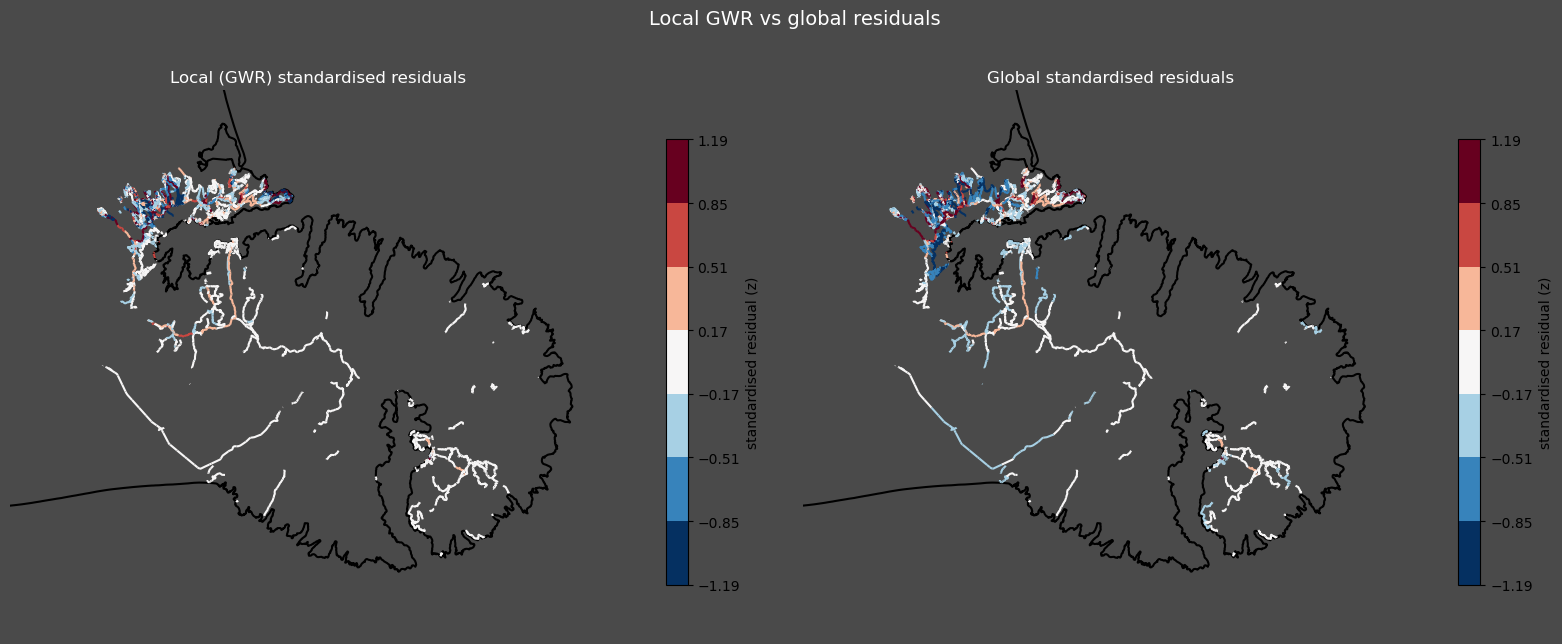

In [178]:
from matplotlib.colors import BoundaryNorm, ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#4a4a4a")

vmax = max(
    np.nanmax(np.abs(gdf["res_std"])),
    np.nanmax(np.abs(gdf["res_global_std"])),
)/10
boundaries = np.linspace(-vmax, vmax, 8)
norm = BoundaryNorm(boundaries, ncolors=7, clip=True)
residual_cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, 7)))

for ax in axes:
    ax.set_facecolor("#4a4a4a")

plot_border_under(axes[0])
gdf.plot(column="res_std", ax=axes[0], cmap=residual_cmap, norm=norm, markersize=10,
         legend=True, legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"}, zorder=2)
zoom_to_data(axes[0])
axes[0].set_title("Local (GWR) standardised residuals", color="white")
axes[0].set_axis_off()

plot_border_under(axes[1])
gdf.plot(column="res_global_std", ax=axes[1], cmap=residual_cmap, norm=norm, markersize=10,
         legend=True, legend_kwds={"shrink": 0.7, "label": "standardised residual (z)"}, zorder=2)
zoom_to_data(axes[1])
axes[1].set_title("Global standardised residuals", color="white")
axes[1].set_axis_off()

fig.suptitle("Local GWR vs global residuals", fontsize=14, color="white")
fig.tight_layout()
plt.show()


## Model fit summary

Pulls the headline diagnostics (deviance, log-likelihood, pseudo-R², AIC, AICc) out of `measures`
and `global_measures` for a side-by-side comparison, plus the effective number of parameters
(`ENP`) per term and the fitted bandwidth.


In [179]:
def measures_to_series(measures_da):
    return pd.Series(np.asarray(measures_da), index=[str(x) for x in measures_da['dim_0'].values])

if isinstance(results, dict):
    bw = results.get("general_bandwidth")
    print("Bandwidth:", bw)

    if "measures" in results and "global_model" in globals():
        gwr_measures = measures_to_series(results["measures"])
        aic_comparison = pd.DataFrame({
            "Model": ["GWR", "Global negative binomial"],
            "AIC": [gwr_measures.get("AIC", np.nan), global_model.aic],
        }).set_index("Model")
        print("\nAIC comparison:")
        display(aic_comparison)

    #if "ENP" in results:
    #    enp = measures_to_series(results["ENP"]) if hasattr(results["ENP"], "coords") else pd.Series(results["ENP"])
    #    print("\nEffective number of parameters per term:")
    #    display(enp)


Bandwidth: [264.]

AIC comparison:


,AIC
Model,
GWR,72577.066784
Global negative binomial,76018.005062


In [175]:
global_coef = global_results["coef_table"].copy()
gwr_terms = [
    column[2:]
    for column in gdf.columns
    if column.startswith("b_") and column not in EXCLUDE_FROM_COEF_PLOTS
]
excluded_global_terms = [
    term for term in global_coef["term"]
    if term not in gwr_terms and term not in ("(Intercept)", "Intercept", "alpha")
]
if excluded_global_terms:
    print("Global terms without matching GWR local estimates:", excluded_global_terms)

rows = []
for _, global_row in global_coef.iterrows():
    term = str(global_row["term"])
    if term in ("(Intercept)", "Intercept", "alpha") or term not in gwr_terms:
        continue

    local_values = gdf[f"b_{term}"].astype(float)
    significance = "*" if float(global_row["p.value"]) < 0.05 else ""
    rows.append({
        "Variable": term,
        "Global regression b": float(global_row["estimate"]),
        "Global t-value": f"{float(global_row['statistic']):.3f}{significance}",
        "GWR b(i) Min": local_values.min(),
        "GWR b(i) Max": local_values.max(),
        "GWR b(i) Mean": local_values.mean(),
        "GWR b(i) StDev": local_values.std(),
    })

parameter_comparison = pd.DataFrame(rows).set_index("Variable")
display(parameter_comparison.style.format({
    "Global regression b": "{:.4g}",
    "GWR b(i) Min": "{:.4g}",
    "GWR b(i) Max": "{:.4g}",
    "GWR b(i) Mean": "{:.4g}",
    "GWR b(i) StDev": "{:.4g}",
}))

Global terms without matching GWR local estimates: ['elevation_range']


,Global regression b,Global t-value,GWR b(i) Min,GWR b(i) Max,GWR b(i) Mean,GWR b(i) StDev
Variable,,,,,,
closeness_centrality,579,29.309*,-6764,5772,667,1266
parking_distance,-5.152e-05,-3.740*,-0.01118,0.007395,-0.0004272,0.001809
elevation_max,-0.001842,-12.651*,-0.06986,0.02522,-0.00547,0.011
trail_density_400m,-20.73,-14.870*,-175.8,390.1,-14.05,49.11
degree_centrality,2381,6.232*,-9605,1.398e+04,486.3,3326
